#### Autor: Rainiero Mendoza de Jesus ***6/4/2026***

In [2]:
# Import the libraries

import csv
from pathlib import Path as Path
import matplotlib.pyplot as plt
from datetime import datetime

In [3]:
# We extract the data from the csv file

path = Path('../data/puerto_plata.csv')
lines = path.read_text(encoding='utf-8').splitlines()
reader = csv.reader(lines)
headers_row = next(reader)

In [4]:
# We explore the fields that our csv file has

for index,x in enumerate(headers_row):
    print(index, x)

0 STATION
1 NAME
2 LATITUDE
3 LONGITUDE
4 ELEVATION
5 DATE
6 TAVG
7 TAVG_ATTRIBUTES
8 TMAX
9 TMAX_ATTRIBUTES
10 TMIN
11 TMIN_ATTRIBUTES


In [5]:
# We extract the columns we want

date = headers_row.index('DATE')
tavg = headers_row.index('TAVG')
tmax = headers_row.index('TMAX')
tmin = headers_row.index('TMIN')
station = headers_row.index('STATION')
name = headers_row.index('NAME')

In [6]:
data = []

for i in reader:

    date_current = datetime.strptime(i[date], '%Y-%m-%d')
    year_current = int(date_current.strftime('%Y'))
    
    station_current = i[station]
    tavg_value = i[tavg]
    tmax_value = i[tmax]
    tmin_value = i[tmin]

    if station_current != 'DRM00078458':
        break

    if data:

        last_dict = data[-1]

        if year_current == last_dict['Year']:

            if tavg_value and tavg_value != 'NaN':
                last_dict['ANUAL TAVG LIST'].append(float(tavg_value))

            if tmax_value and tmax_value != 'NaN':
                last_dict['ANUAL TMAX LIST'].append(float(tmax_value))

            if tmin_value and tmin_value != 'NaN':
                last_dict['ANUAL TMIN LIST'].append(float(tmin_value))

        else:

            new_dict = {
                'Year': year_current,
                'ANUAL TAVG LIST': [],
                'ANUAL TMAX LIST': [],
                'ANUAL TMIN LIST': []
            }

            if tavg_value and tavg_value != 'NaN':
                new_dict['ANUAL TAVG LIST'].append(float(tavg_value))

            if tmax_value and tmax_value != 'NaN':
                new_dict['ANUAL TMAX LIST'].append(float(tmax_value))

            if tmin_value and tmin_value != 'NaN':
                new_dict['ANUAL TMIN LIST'].append(float(tmin_value))

            data.append(new_dict)

    else:

        new_dict = {
            'Year': year_current,
            'ANUAL TAVG LIST': [],
            'ANUAL TMAX LIST': [],
            'ANUAL TMIN LIST': []
        }

        if tavg_value and tavg_value != 'NaN':
            new_dict['ANUAL TAVG LIST'].append(float(tavg_value))

        if tmax_value and tmax_value != 'NaN':
            new_dict['ANUAL TMAX LIST'].append(float(tmax_value))

        if tmin_value and tmin_value != 'NaN':
            new_dict['ANUAL TMIN LIST'].append(float(tmin_value))

        data.append(new_dict)

In [7]:
# We verify the structure we created

print(data[:2])

[{'Year': 2000, 'ANUAL TAVG LIST': [76.0, 73.0, 76.0, 76.0, 78.0, 76.0, 77.0, 73.0, 72.0, 75.0, 71.0, 74.0, 73.0, 80.0, 76.0, 77.0, 76.0, 76.0, 74.0, 77.0, 74.0, 76.0, 76.0, 76.0, 77.0, 77.0, 76.0, 76.0, 76.0, 80.0, 77.0, 76.0, 80.0, 77.0, 80.0, 77.0, 76.0, 76.0, 76.0, 74.0, 75.0, 76.0, 75.0, 75.0, 76.0, 78.0, 73.0, 75.0, 74.0, 71.0, 77.0, 81.0, 77.0, 79.0, 79.0, 76.0, 77.0, 81.0, 79.0, 76.0, 76.0, 77.0, 74.0, 79.0, 80.0, 77.0, 78.0, 80.0, 80.0, 78.0, 79.0, 78.0, 79.0, 78.0, 80.0, 80.0, 81.0, 80.0, 78.0, 79.0, 80.0, 80.0, 81.0, 81.0, 79.0, 79.0, 81.0, 80.0, 78.0, 80.0, 83.0, 82.0, 82.0, 83.0, 82.0, 82.0, 81.0, 77.0, 77.0, 81.0, 78.0, 77.0, 80.0, 80.0, 80.0, 80.0, 80.0, 81.0, 82.0, 81.0, 80.0, 83.0, 81.0, 88.0, 80.0, 80.0, 79.0, 80.0, 83.0, 83.0, 83.0, 84.0, 83.0, 84.0, 83.0, 83.0, 81.0, 83.0, 83.0, 83.0, 84.0, 80.0, 80.0, 82.0, 85.0, 84.0, 84.0, 84.0, 83.0, 82.0, 78.0, 79.0, 82.0, 80.0, 81.0, 83.0, 84.0, 82.0, 83.0, 83.0, 83.0, 82.0, 83.0, 83.0, 85.0, 79.0, 84.0, 84.0, 84.0, 84.0, 83.0

In [8]:

data_00_12 = data[0:13:1]
data_13_24 = data[13:26:1]

print(data_00_12[:2])
print(data_13_24[:2])

[{'Year': 2000, 'ANUAL TAVG LIST': [76.0, 73.0, 76.0, 76.0, 78.0, 76.0, 77.0, 73.0, 72.0, 75.0, 71.0, 74.0, 73.0, 80.0, 76.0, 77.0, 76.0, 76.0, 74.0, 77.0, 74.0, 76.0, 76.0, 76.0, 77.0, 77.0, 76.0, 76.0, 76.0, 80.0, 77.0, 76.0, 80.0, 77.0, 80.0, 77.0, 76.0, 76.0, 76.0, 74.0, 75.0, 76.0, 75.0, 75.0, 76.0, 78.0, 73.0, 75.0, 74.0, 71.0, 77.0, 81.0, 77.0, 79.0, 79.0, 76.0, 77.0, 81.0, 79.0, 76.0, 76.0, 77.0, 74.0, 79.0, 80.0, 77.0, 78.0, 80.0, 80.0, 78.0, 79.0, 78.0, 79.0, 78.0, 80.0, 80.0, 81.0, 80.0, 78.0, 79.0, 80.0, 80.0, 81.0, 81.0, 79.0, 79.0, 81.0, 80.0, 78.0, 80.0, 83.0, 82.0, 82.0, 83.0, 82.0, 82.0, 81.0, 77.0, 77.0, 81.0, 78.0, 77.0, 80.0, 80.0, 80.0, 80.0, 80.0, 81.0, 82.0, 81.0, 80.0, 83.0, 81.0, 88.0, 80.0, 80.0, 79.0, 80.0, 83.0, 83.0, 83.0, 84.0, 83.0, 84.0, 83.0, 83.0, 81.0, 83.0, 83.0, 83.0, 84.0, 80.0, 80.0, 82.0, 85.0, 84.0, 84.0, 84.0, 83.0, 82.0, 78.0, 79.0, 82.0, 80.0, 81.0, 83.0, 84.0, 82.0, 83.0, 83.0, 83.0, 82.0, 83.0, 83.0, 85.0, 79.0, 84.0, 84.0, 84.0, 84.0, 83.0

In [9]:
# We create lists where we store the data already processed and ready to graph

years, anual_tmaxs, anual_tmins = [], [], []
anual_tavgs = []

years_parte1, tmaxs_parte1, tmins_parte1 = [], [], []
tavgs_parte1 = []

years_parte2, tmaxs_parte2, tmins_parte2 = [], [], []
tavgs_parte2 = []

In [10]:
# Once the data is grouped, we perform the desired operations

def cambio_lista(value_list, value_years, value_tmax, value_tmin, value_tavg):
    for i in value_list:
        year = i['Year']
        value_years.append(year)

        tmax = i['ANUAL TMAX LIST']
        tmax_len = len(tmax)
        valor_final = sum(tmax)/tmax_len
        value_tmax.append(valor_final)

        tmin = i['ANUAL TMIN LIST']
        tmin_len = len(tmin)
        valor_mins = sum(tmin)/tmin_len
        value_tmin.append(valor_mins)

        tavg = i['ANUAL TAVG LIST']
        tavg_len = len(tavg)
        valor_tavg = sum(tavg)/tavg_len
        value_tavg.append(valor_tavg)

In [11]:
cambio_lista(value_list=data, value_years=years,value_tmax=anual_tmaxs, value_tmin=anual_tmins, value_tavg=anual_tavgs)
cambio_lista(value_list=data_00_12, value_years=years_parte1,value_tmax=tmaxs_parte1, value_tmin=tmins_parte1, value_tavg=tavgs_parte1)
cambio_lista(value_list=data_13_24, value_years=years_parte2,value_tmax=tmaxs_parte2, value_tmin=tmins_parte2, value_tavg=tavgs_parte2)

In [12]:
# Exploramos las listas para verificar 

print(years)
print(anual_tmaxs)
print(anual_tmins)
print(anual_tavgs)

[2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
[88.68253968253968, 88.59248554913295, 89.36494252873563, 90.10787172011662, 87.64638783269962, 87.21069182389937, 89.03973509933775, 88.62658227848101, 87.55205047318611, 87.85882352941177, 87.83841463414635, 87.85545722713864, 88.19076923076923, 88.43514644351464, 90.16521739130435, 89.26646706586827, 89.34957020057307, 89.92, 90.97126436781609, 90.55084745762711, 89.11888111888112, 89.44884488448845, 90.08333333333333, 89.05956112852665]
[68.58412698412698, 68.92774566473989, 67.84770114942529, 68.9795918367347, 69.63117870722434, 69.67924528301887, 68.91059602649007, 70.43037974683544, 69.78864353312302, 70.26764705882353, 70.84146341463415, 69.54277286135694, 69.65230769230769, 69.98326359832636, 71.08115942028985, 69.03892215568862, 70.61604584527221, 70.53428571428572, 70.9396551724138, 70.9322033898305, 68.98601398601399, 69.0792079207

In [13]:
print(years_parte1)
print(tmaxs_parte1)
print(tmins_parte1)
print(tavgs_parte1)

[2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012]
[88.68253968253968, 88.59248554913295, 89.36494252873563, 90.10787172011662, 87.64638783269962, 87.21069182389937, 89.03973509933775, 88.62658227848101, 87.55205047318611, 87.85882352941177, 87.83841463414635, 87.85545722713864, 88.19076923076923]
[68.58412698412698, 68.92774566473989, 67.84770114942529, 68.9795918367347, 69.63117870722434, 69.67924528301887, 68.91059602649007, 70.43037974683544, 69.78864353312302, 70.26764705882353, 70.84146341463415, 69.54277286135694, 69.65230769230769]
[80.59643916913947, 78.94957983193277, 79.63736263736264, 80.06111111111112, 79.48511904761905, 80.50450450450451, 79.91071428571429, 79.0813953488372, 78.34571428571428, 78.13186813186813, 78.36164383561643, 78.66849315068494, 79.11864406779661]


In [14]:
print(years_parte2)
print(tmaxs_parte2)
print(tmins_parte2)
print(tavgs_parte2)

[2013, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
[88.43514644351464, 90.16521739130435, 89.26646706586827, 89.34957020057307, 89.92, 90.97126436781609, 90.55084745762711, 89.11888111888112, 89.44884488448845, 90.08333333333333, 89.05956112852665]
[69.98326359832636, 71.08115942028985, 69.03892215568862, 70.61604584527221, 70.53428571428572, 70.9396551724138, 70.9322033898305, 68.98601398601399, 69.07920792079207, 71.59166666666667, 72.02507836990596]
[79.98455598455598, 79.86118980169972, 78.89256198347107, 78.4573002754821, 78.60497237569061, 79.6978021978022, 79.39285714285714, 77.98675496688742, 78.06997084548105, 79.12146892655367, 79.20797720797721]


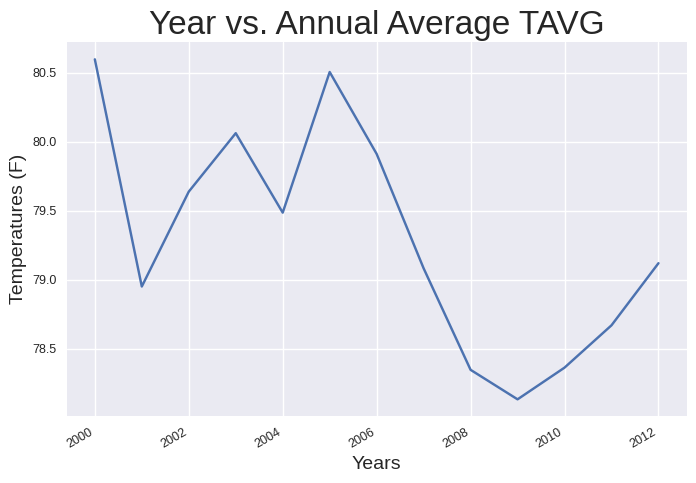

In [15]:
# Make a plot, 2000-2012 Year vs. Annual Average TAVG

plt.style.use('seaborn-v0_8')

fig, ax = plt.subplots()
title = "Year vs. Annual Average TAVG"
ax.plot(years_parte1, tavgs_parte1)
ax.set_ylabel('Temperatures (F)', fontsize=14)
ax.set_xlabel('Years', fontsize=14)
ax.set_title(title, fontsize=24)
ax.tick_params(labelsize=9)
fig.autofmt_xdate()

plt.show()

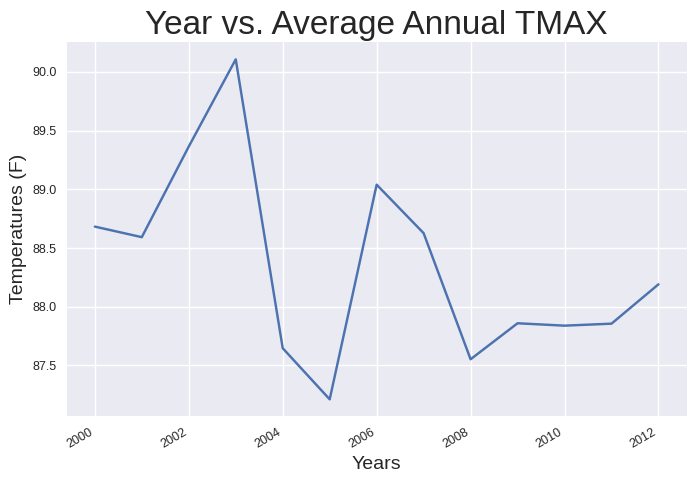

In [16]:
# Make a plots, 2000-2012 Year vs. Average Annual TMAX

plt.style.use('seaborn-v0_8')

title = "Year vs. Average Annual TMAX"
fig, ax = plt.subplots()
ax.plot(years_parte1, tmaxs_parte1)
ax.set_ylabel('Temperatures (F)', fontsize=14)
ax.set_xlabel('Years', fontsize=14)
ax.set_title(title, fontsize=24)
ax.tick_params(labelsize=9)
fig.autofmt_xdate()

plt.show()

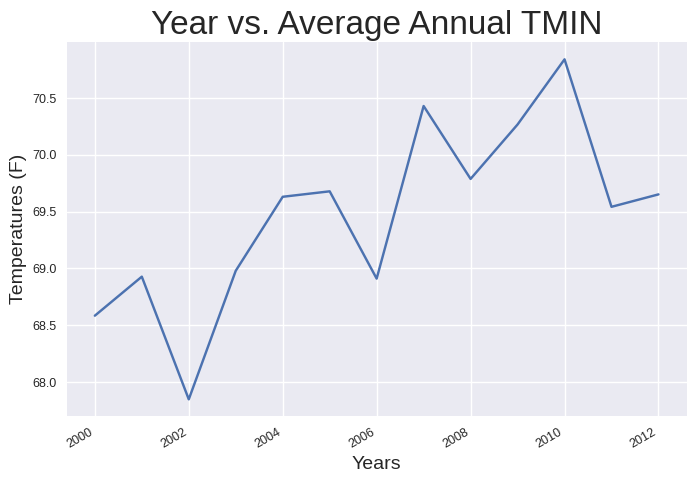

In [17]:
# Make a plot, 2000-2012 Year vs. Average Annual TMIN

plt.style.use('seaborn-v0_8')

title = "Year vs. Average Annual TMIN"
fig, ax = plt.subplots()
ax.plot(years_parte1, tmins_parte1)
ax.set_ylabel('Temperatures (F)', fontsize=14)
ax.set_xlabel('Years', fontsize=14)
ax.set_title(title, fontsize=24)
ax.tick_params(labelsize=9)
fig.autofmt_xdate()

plt.show()

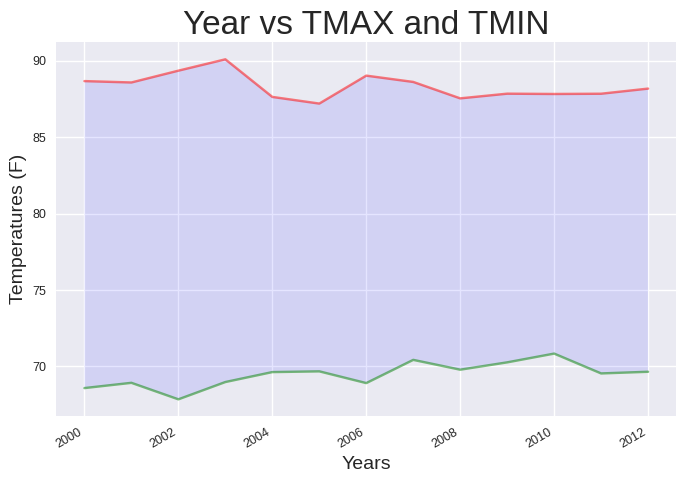

In [18]:
# Make a plot, 2000-2012 Year vs TMAX and TMIN

plt.style.use('seaborn-v0_8')

fig, ax = plt.subplots()
title = "Year vs TMAX and TMIN"
ax.plot(years_parte1, tmaxs_parte1, color='red', alpha=0.5)
ax.plot(years_parte1, tmins_parte1, color='green', alpha=0.5)
ax.fill_between(years_parte1, tmaxs_parte1, tmins_parte1, alpha=0.1, facecolor='blue')

ax.set_ylabel('Temperatures (F)', fontsize=14)
ax.set_xlabel('Years', fontsize=14)
ax.set_title(title, fontsize=24)
ax.tick_params(labelsize=9)
fig.autofmt_xdate()

plt.show()

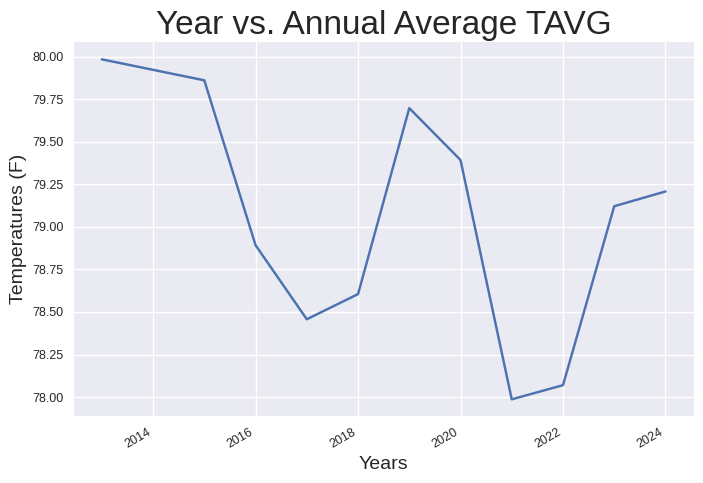

In [19]:
# Make a plot, 2013-2024 Year vs. Annual Average TAVG

plt.style.use('seaborn-v0_8')

fig, ax = plt.subplots()
title = "Year vs. Annual Average TAVG"
ax.plot(years_parte2, tavgs_parte2)
ax.set_ylabel('Temperatures (F)', fontsize=14)
ax.set_xlabel('Years', fontsize=14)
ax.set_title(title, fontsize=24)
ax.tick_params(labelsize=9)
fig.autofmt_xdate()

plt.show()

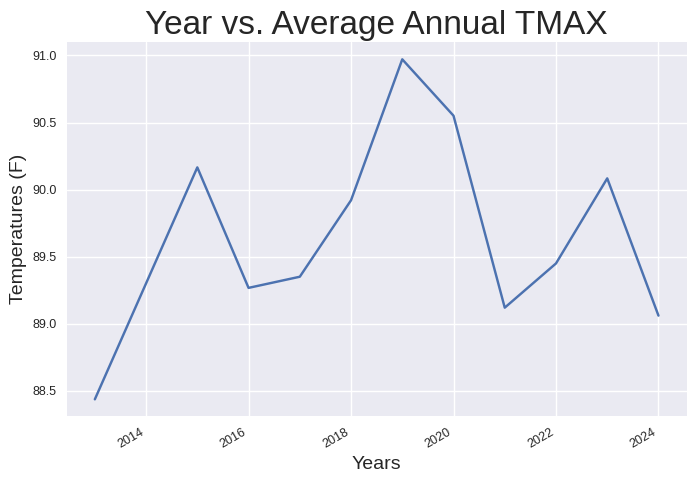

In [20]:
# Make a plots, 2013-2024 Year vs. Average Annual TMAX

plt.style.use('seaborn-v0_8')

title = "Year vs. Average Annual TMAX"
fig, ax = plt.subplots()
ax.plot(years_parte2, tmaxs_parte2)
ax.set_ylabel('Temperatures (F)', fontsize=14)
ax.set_xlabel('Years', fontsize=14)
ax.set_title(title, fontsize=24)
ax.tick_params(labelsize=9)
fig.autofmt_xdate()

plt.show()

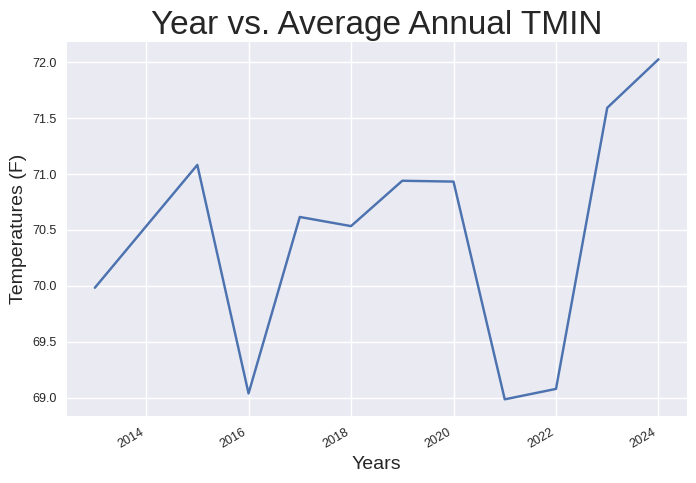

In [21]:
# Make a plot, 2013-2024 Year vs. Average Annual TMIN

plt.style.use('seaborn-v0_8')

title = "Year vs. Average Annual TMIN"
fig, ax = plt.subplots()
ax.plot(years_parte2, tmins_parte2)
ax.set_ylabel('Temperatures (F)', fontsize=14)
ax.set_xlabel('Years', fontsize=14)
ax.set_title(title, fontsize=24)
ax.tick_params(labelsize=9)
fig.autofmt_xdate()

plt.show()

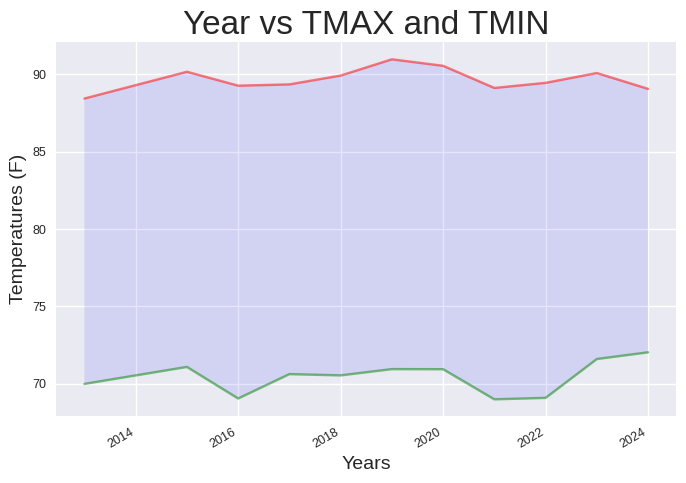

In [22]:
# Make a plot, 2013-2024 Year vs TMAX and TMIN

plt.style.use('seaborn-v0_8')

fig, ax = plt.subplots()
title = "Year vs TMAX and TMIN"
ax.plot(years_parte2, tmaxs_parte2, color='red', alpha=0.5)
ax.plot(years_parte2, tmins_parte2, color='green', alpha=0.5)
ax.fill_between(years_parte2, tmaxs_parte2, tmins_parte2, alpha=0.1, facecolor='blue')

ax.set_ylabel('Temperatures (F)', fontsize=14)
ax.set_xlabel('Years', fontsize=14)
ax.set_title(title, fontsize=24)
ax.tick_params(labelsize=9)
fig.autofmt_xdate()

plt.show()

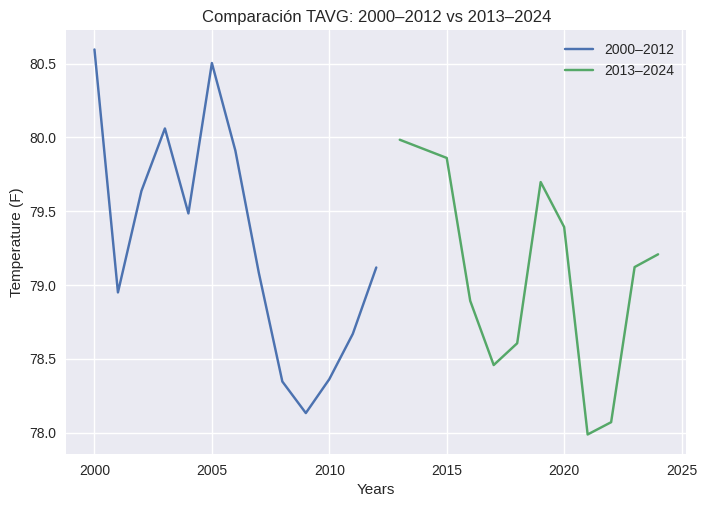

In [23]:
# Comparación TAVG: 2000–2012 vs 2013–2024

plt.style.use('seaborn-v0_8')

fig, ax = plt.subplots()

ax.plot(years_parte1, tavgs_parte1, label='2000–2012')
ax.plot(years_parte2, tavgs_parte2, label='2013–2024')

ax.set_title('Comparación TAVG: 2000–2012 vs 2013–2024')
ax.set_xlabel('Years')
ax.set_ylabel('Temperature (F)')
ax.legend()

plt.show()

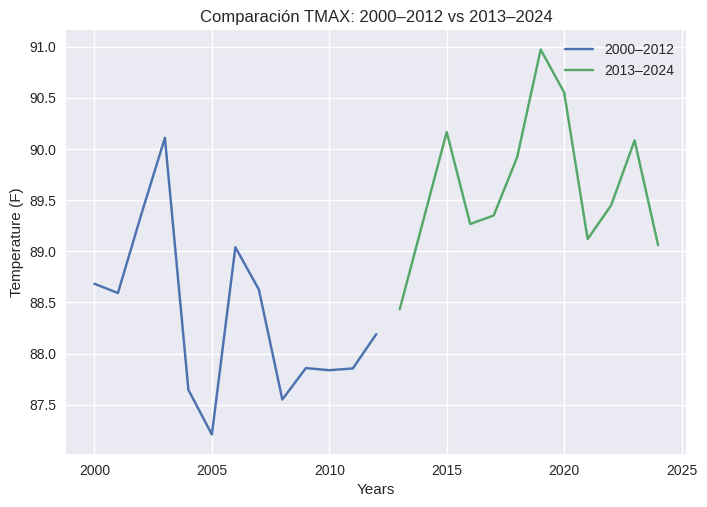

In [24]:
# Comparación TMAX: 2000–2012 vs 2013–2024

plt.style.use('seaborn-v0_8')

fig, ax = plt.subplots()

ax.plot(years_parte1, tmaxs_parte1, label='2000–2012')
ax.plot(years_parte2, tmaxs_parte2, label='2013–2024')

ax.set_title('Comparación TMAX: 2000–2012 vs 2013–2024')
ax.set_xlabel('Years')
ax.set_ylabel('Temperature (F)')
ax.legend()

plt.show()

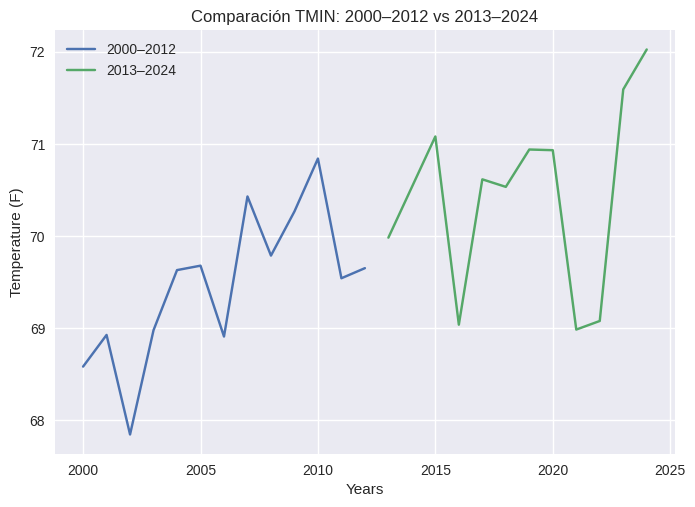

In [25]:
# Comparación TMIN: 2000–2012 vs 2013–2024

plt.style.use('seaborn-v0_8')

fig, ax = plt.subplots()

ax.plot(years_parte1, tmins_parte1, label='2000–2012')
ax.plot(years_parte2, tmins_parte2, label='2013–2024')

ax.set_title('Comparación TMIN: 2000–2012 vs 2013–2024')
ax.set_xlabel('Years')
ax.set_ylabel('Temperature (F)')
ax.legend()

plt.show()